In [1]:
import netCDF4 as nc 
import matplotlib.pyplot as plt
import numpy as np
import itertools
import xarray as xr
import glob
from pathlib import Path
import torch
import patcher
import pandas as pd

In [2]:
DATA_DIR = Path('/Volumes/portable/arpp/data')
patcher_context = patcher.Context(str(DATA_DIR), 16)

In [3]:
ALL_VARS = [f.stem for f in list(DATA_DIR.glob('*.bin'))]
INM_VARS = [v for v in ALL_VARS if v.split("_")[0] == 'inm']
ERA_VARS = [v for v in ALL_VARS if v.split("_")[0] != 'inm']
ERA_VARS.remove('config')
print(f"ERA_VARS:\n {' / '.join(ERA_VARS)}")
print(f"INM_VARS:\n {' / '.join(INM_VARS)}")

ERA_VARS:
 glaicer / snow_cover / sd / sst / t2m / tp / sden / z / sdor / lsm / pt
INM_VARS:
 inm_swe / inm_ts / inm_mslp / inm_tp / inm_u850 / inm_snow_cover / inm_olr / inm_h500 / inm_hlt / inm_ww / inm_v850 / inm_t2m


#### **Dataset**

era_snow_cover_6weeks: torch.Size([6, 361, 1440])
era_snow_cover_6months: torch.Size([6, 361, 1440])
era_sd_6weeks: torch.Size([6, 361, 1440])
era_sd_6months: torch.Size([6, 361, 1440])
era_sst_6weeks: torch.Size([6, 361, 1440])
era_sst_6months: torch.Size([6, 361, 1440])
era_t2m_6weeks: torch.Size([6, 361, 1440])
era_t2m_6months: torch.Size([6, 361, 1440])
era_tp_6weeks: torch.Size([6, 361, 1440])
era_tp_6months: torch.Size([6, 361, 1440])
era_sden_6weeks: torch.Size([6, 361, 1440])
era_sden_6months: torch.Size([6, 361, 1440])
era_pt_6weeks: torch.Size([6, 361, 1440])
era_pt_6months: torch.Size([6, 361, 1440])
inm_swe_17weeks: torch.Size([10, 17, 91, 360])
inm_ts_17weeks: torch.Size([10, 17, 91, 360])
inm_mslp_17weeks: torch.Size([10, 17, 91, 360])
inm_tp_17weeks: torch.Size([10, 17, 91, 360])
inm_u850_17weeks: torch.Size([10, 17, 91, 360])
inm_v850_17weeks: torch.Size([10, 17, 91, 360])
inm_snow_cover_17weeks: torch.Size([10, 17, 91, 360])
inm_olr_17weeks: torch.Size([10, 17, 91, 360

/var/folders/zj/llz5pnt12dqgd3j4hf1bw7_m0000gn/T/ipykernel_12953/1820930475.py:29: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(1, 2)


inm_hlt_17weeks: torch.Size([10, 17, 91, 360])
inm_ww_17weeks: torch.Size([10, 17, 91, 360])
inm_t2m_17weeks: torch.Size([10, 17, 91, 360])
z: torch.Size([1, 361, 1440])
sdor: torch.Size([1, 361, 1440])
lsm: torch.Size([1, 361, 1440])
glaicer: torch.Size([1, 361, 1440])
inm_lead_time_17weeks: torch.Size([17])


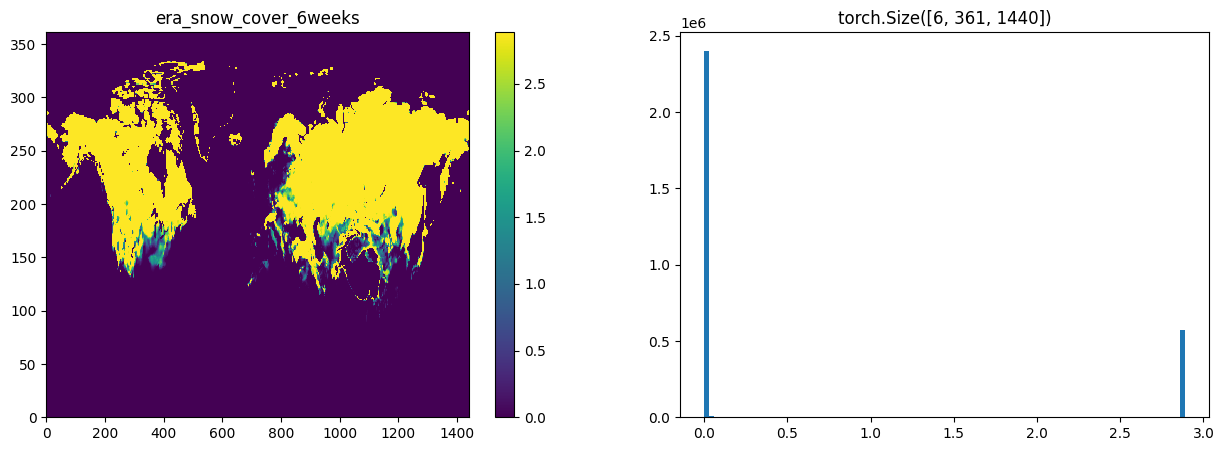

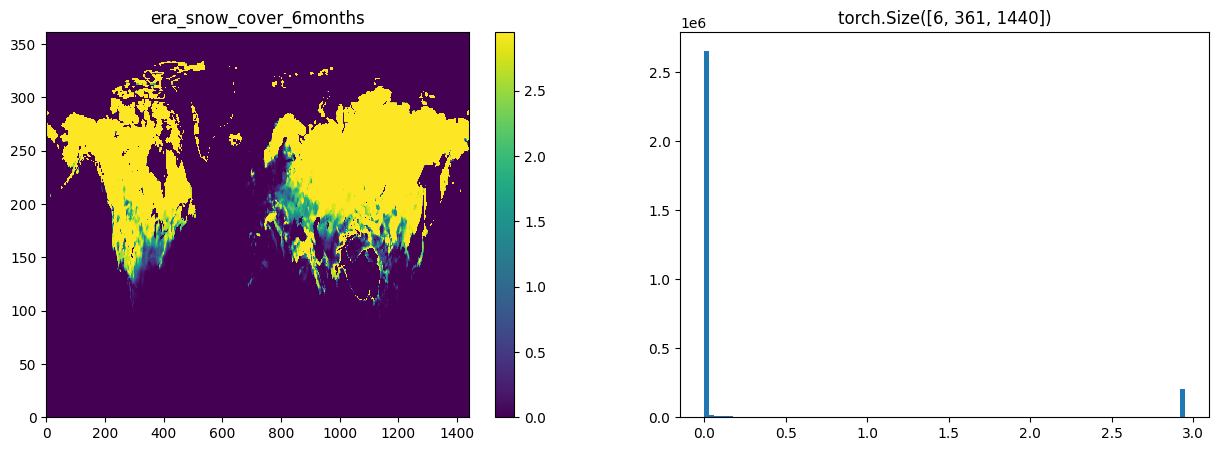

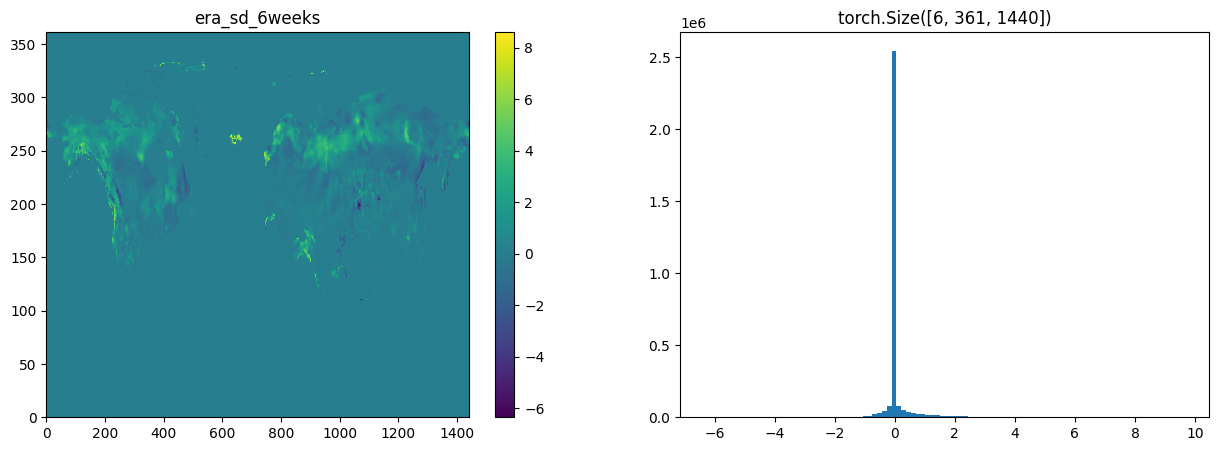

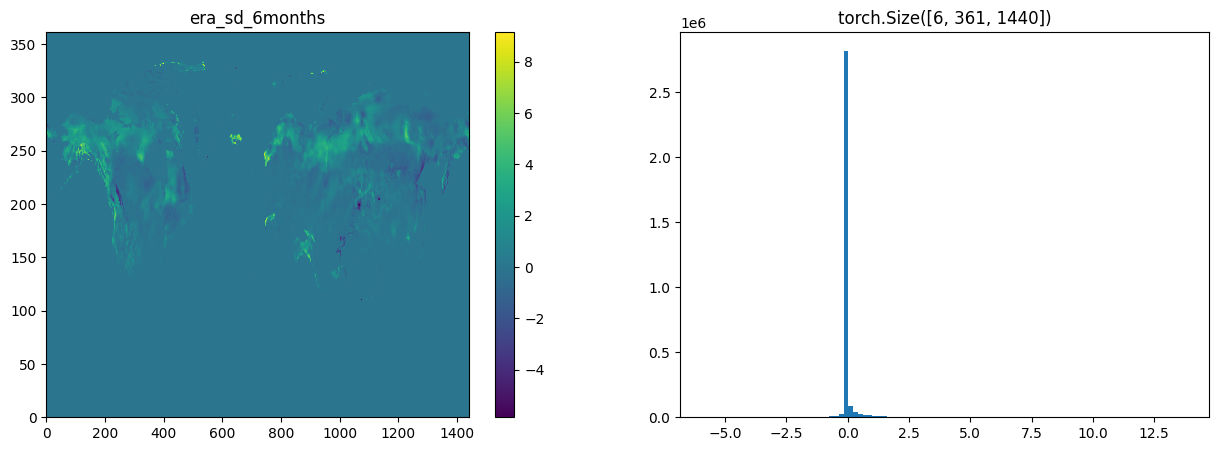

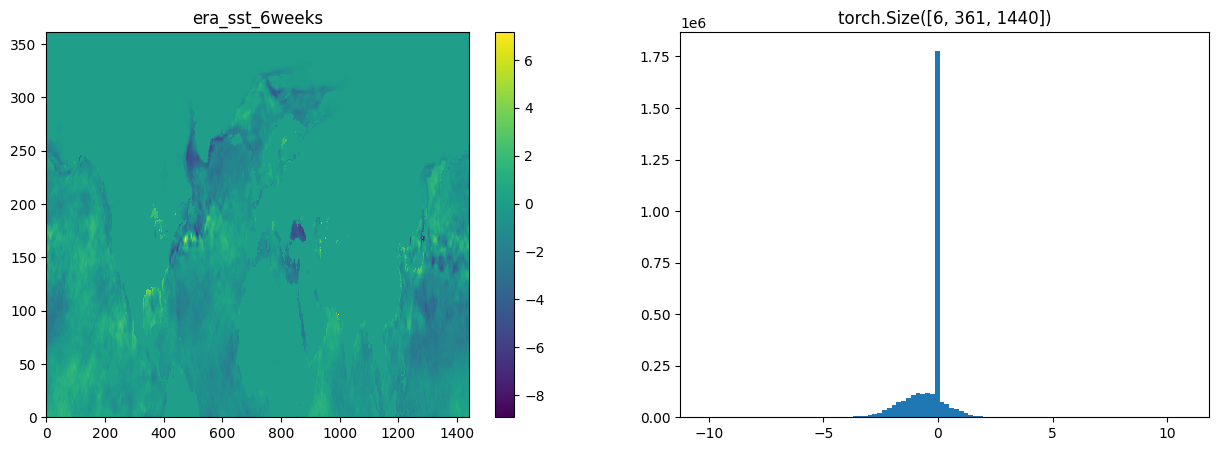

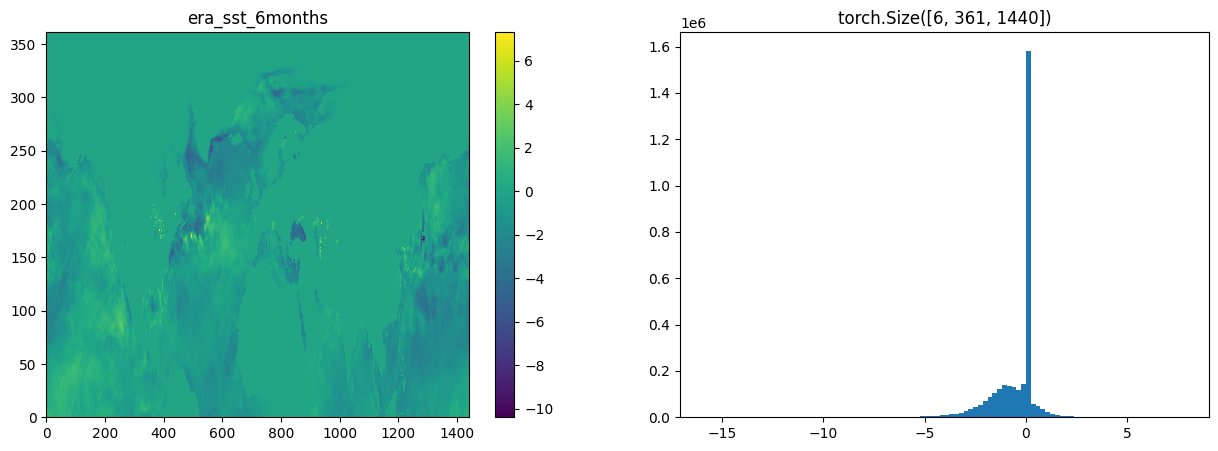

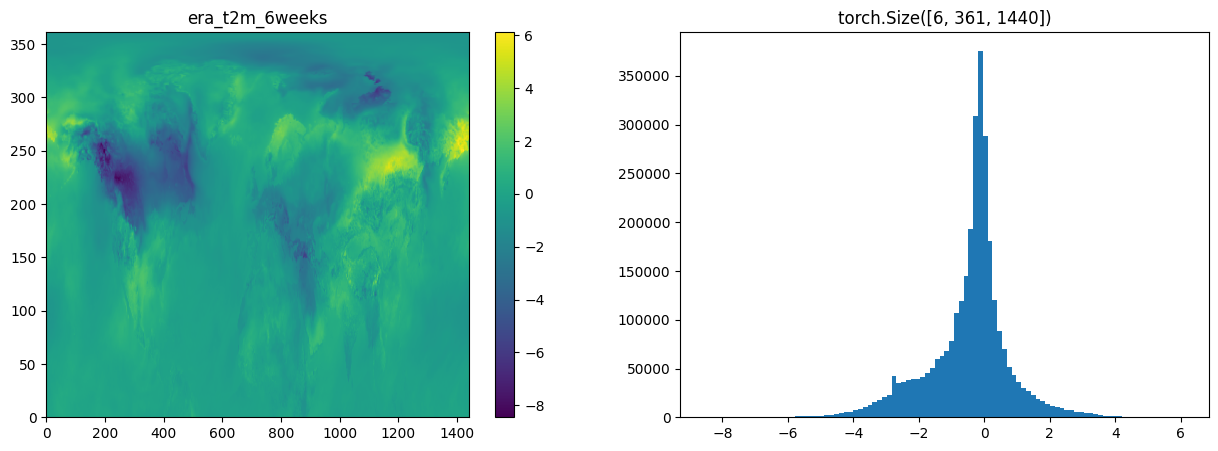

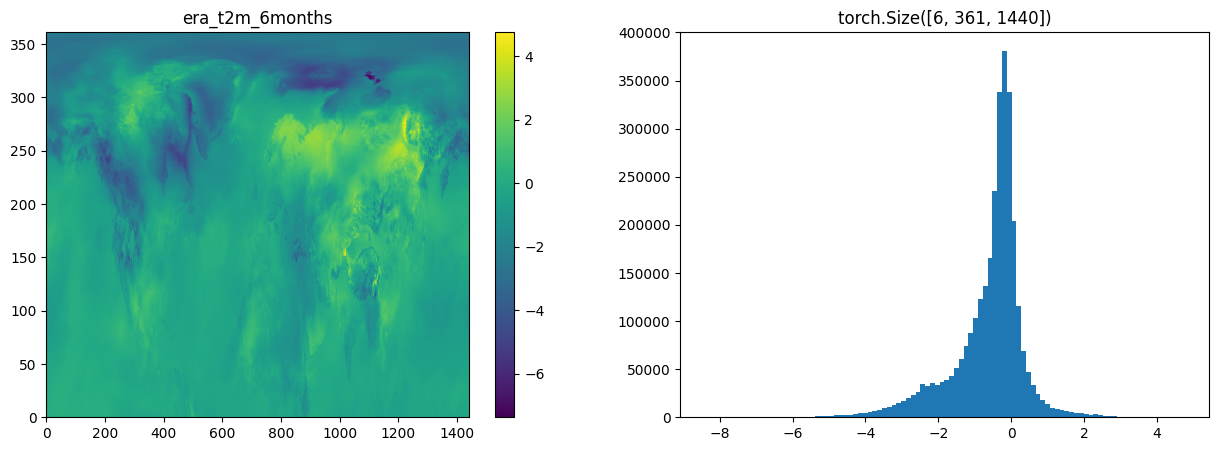

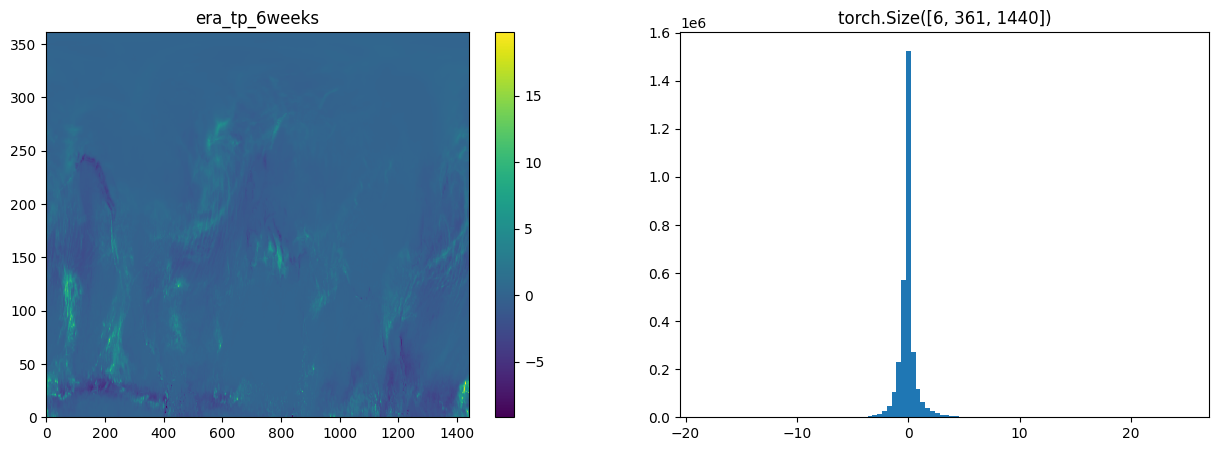

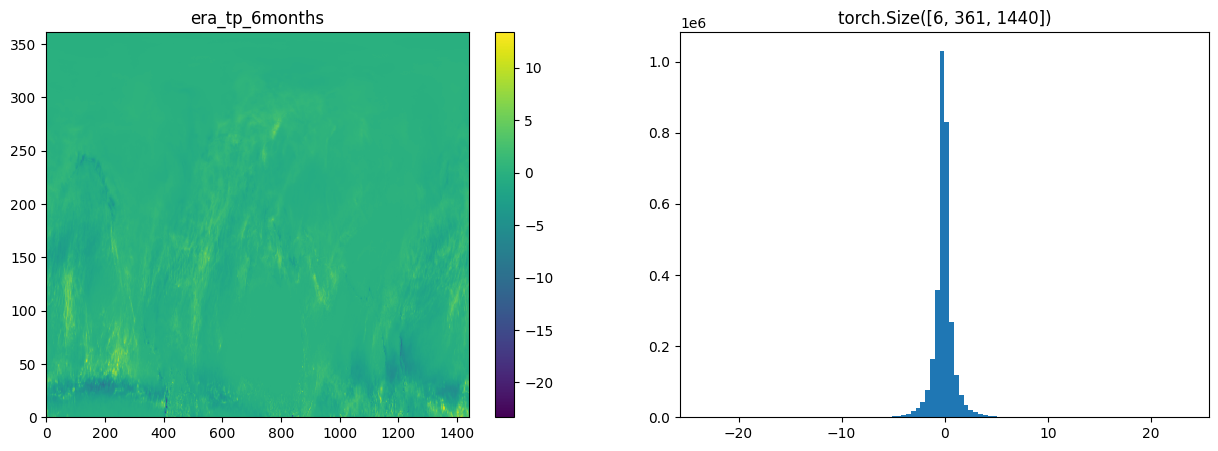

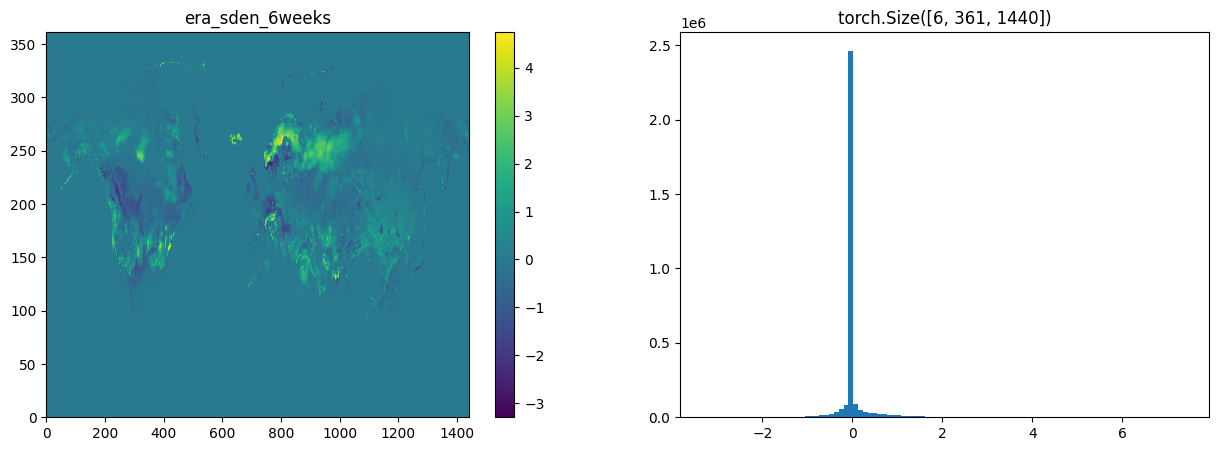

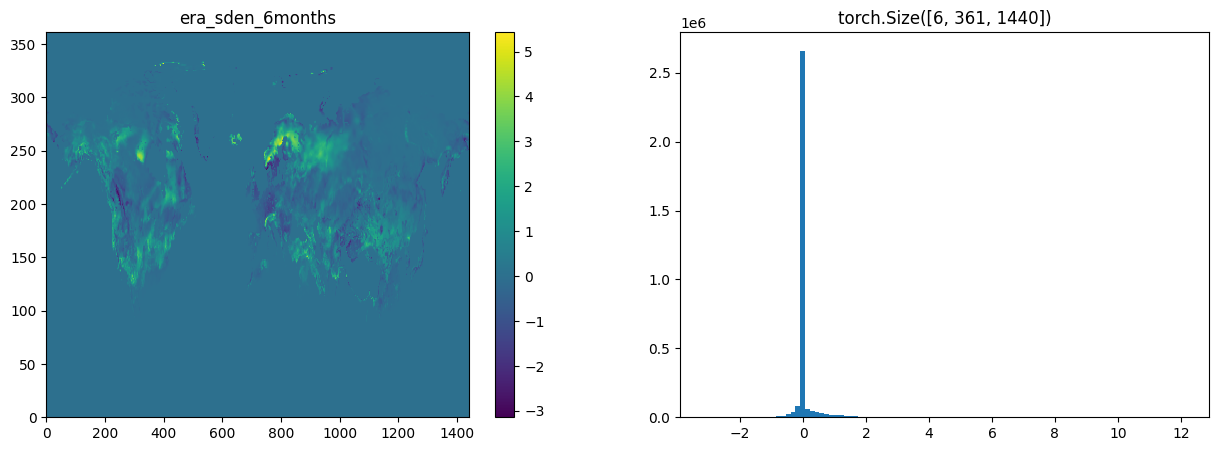

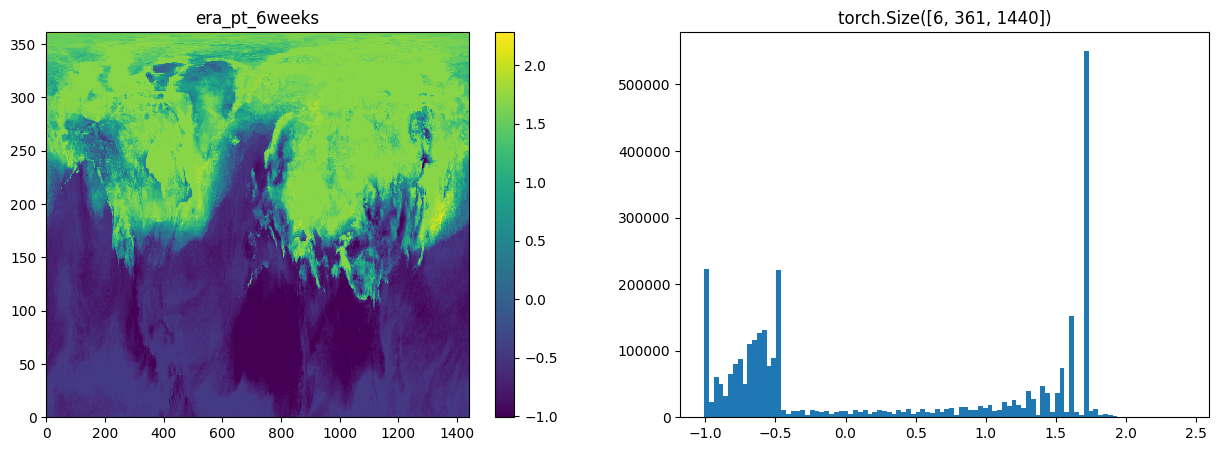

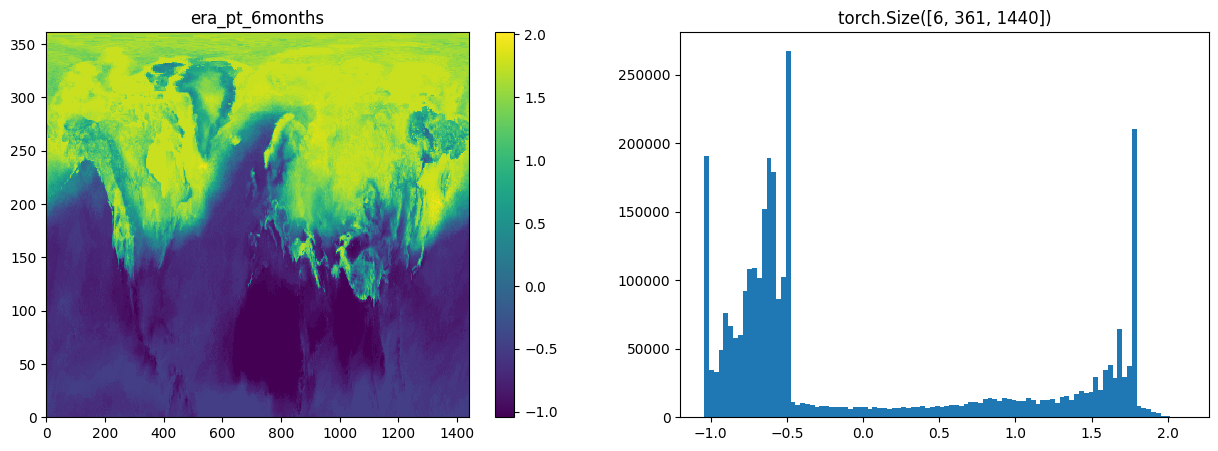

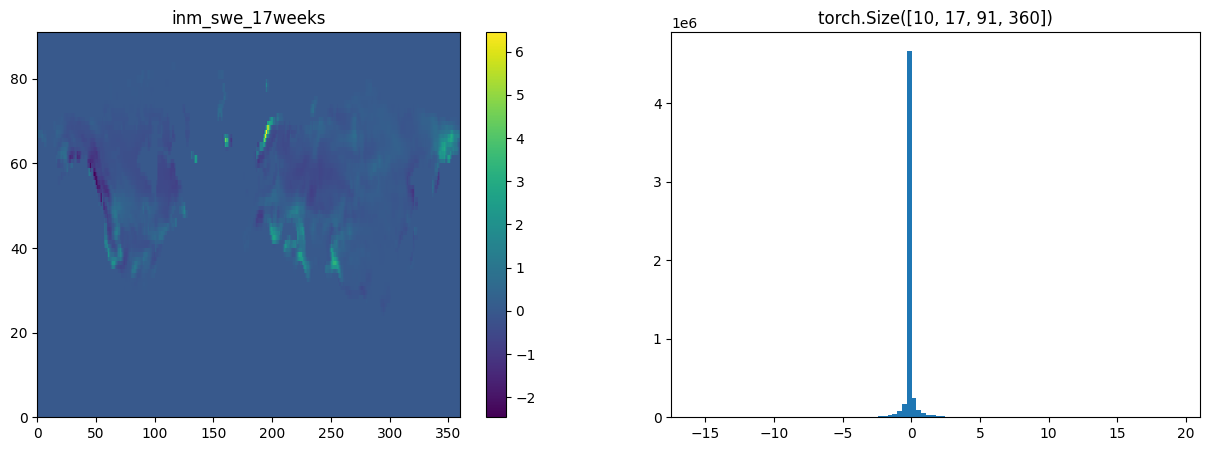

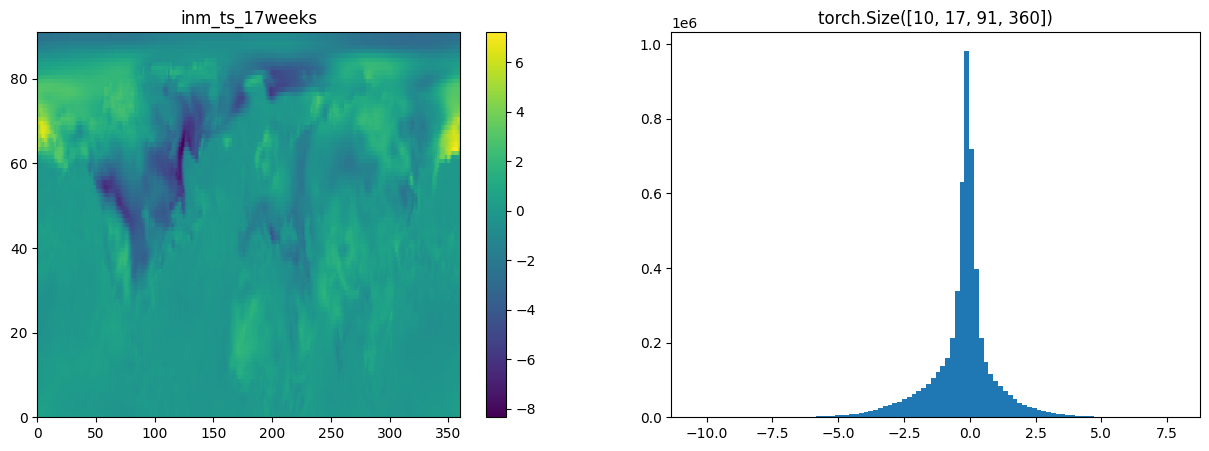

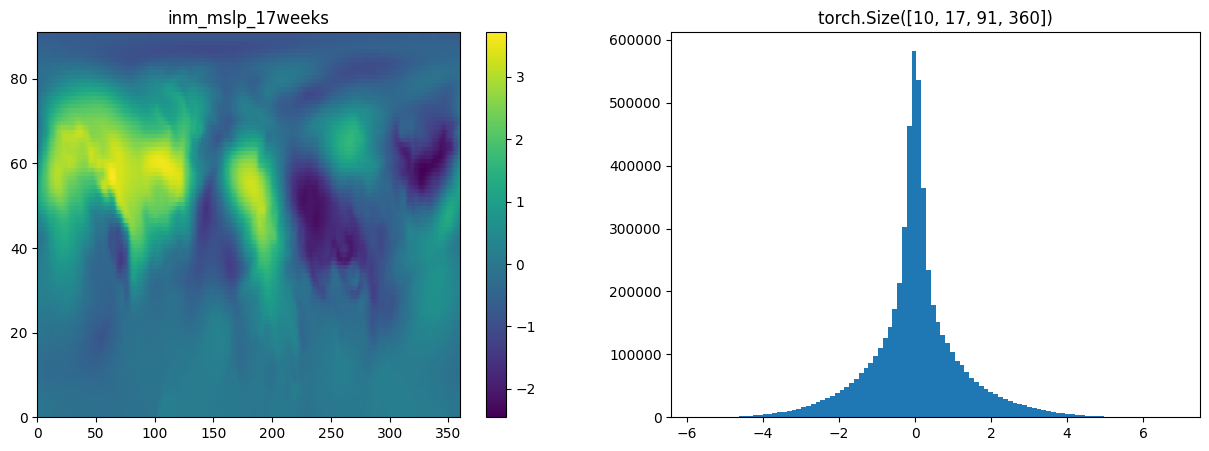

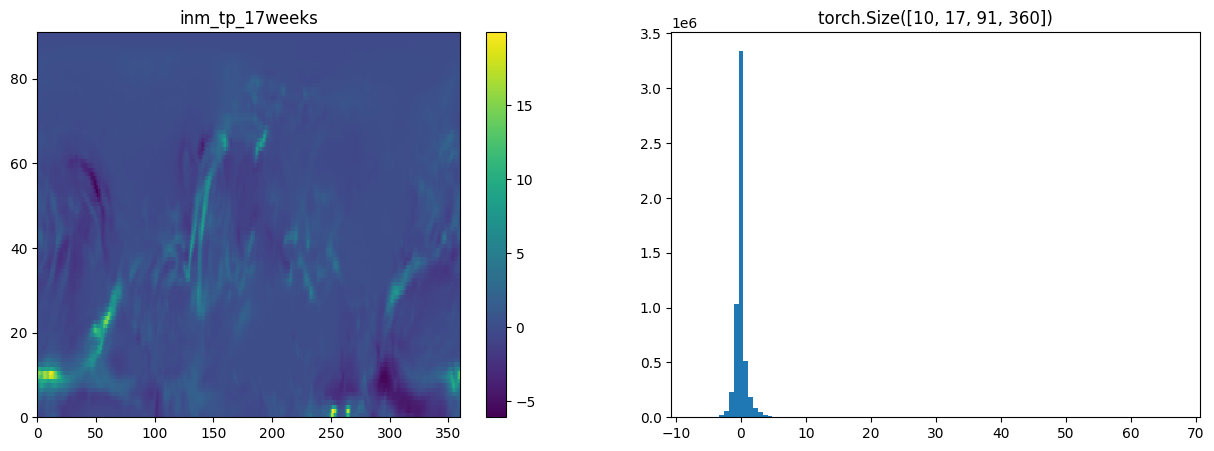

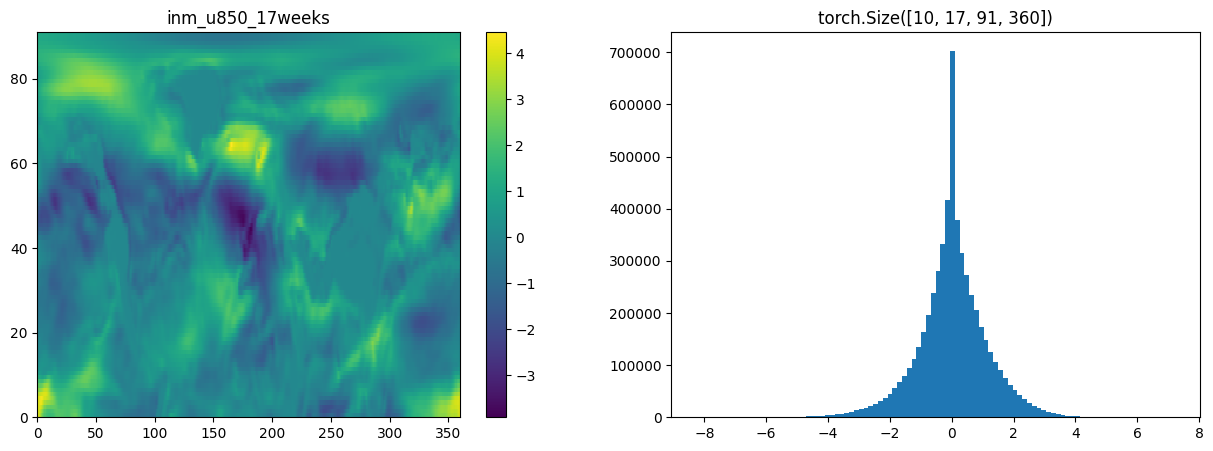

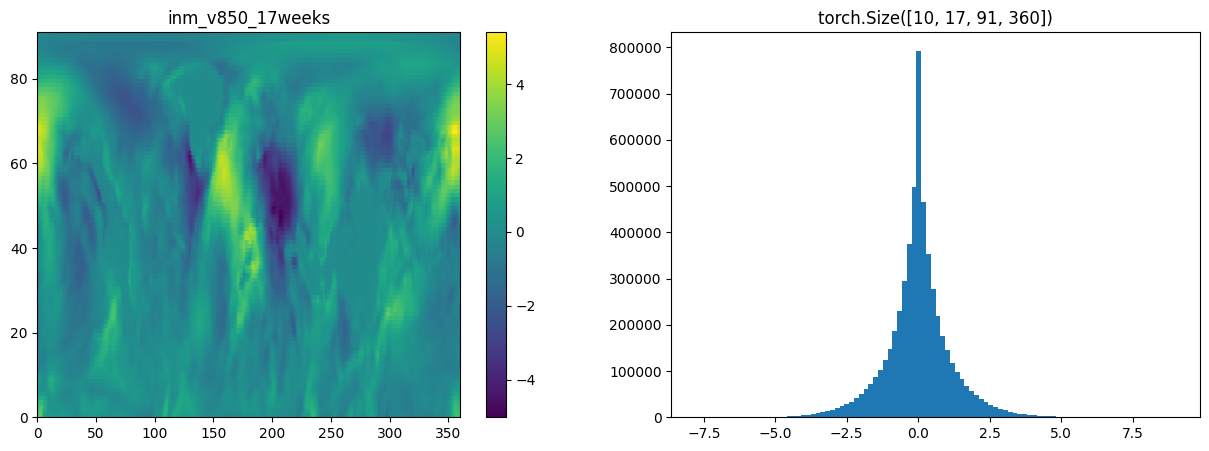

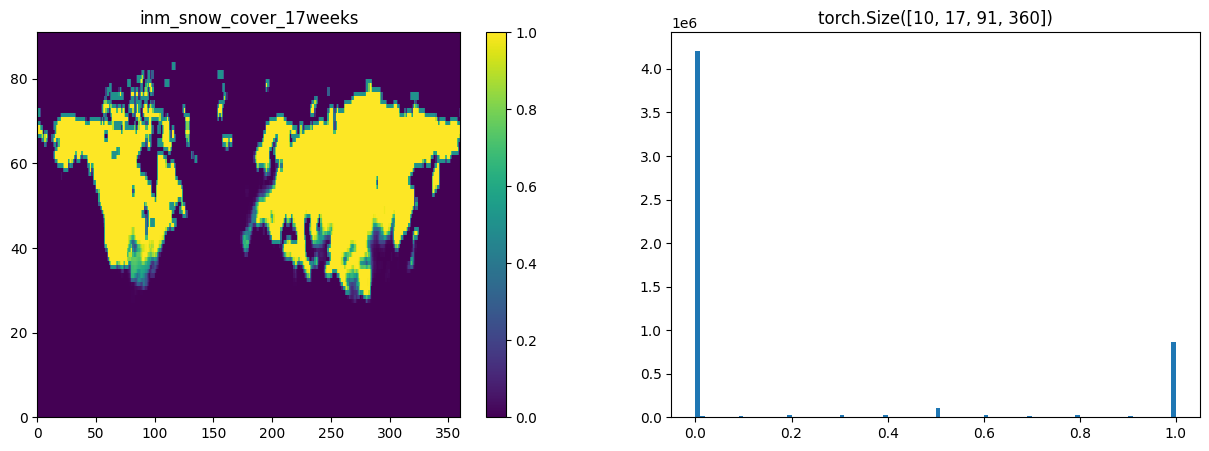

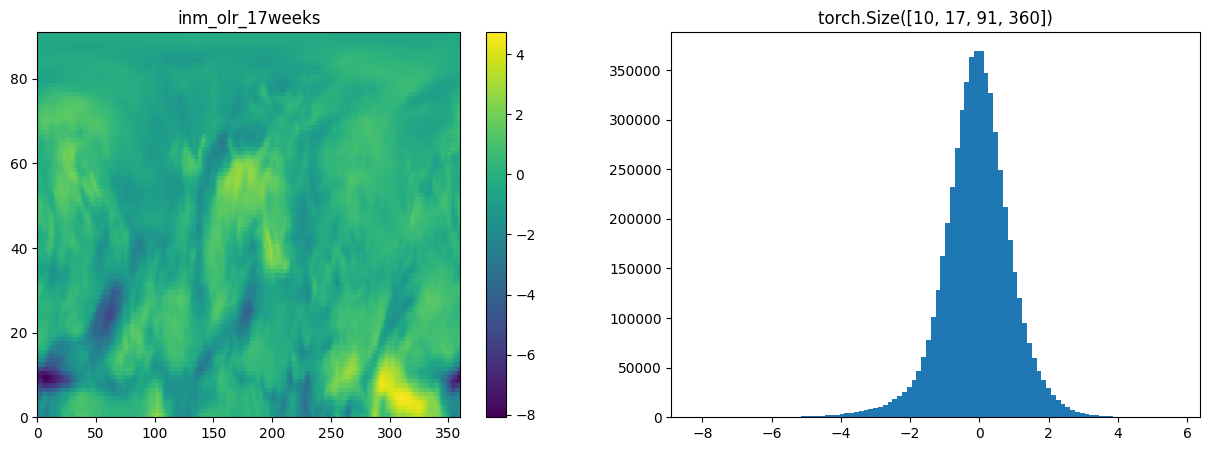

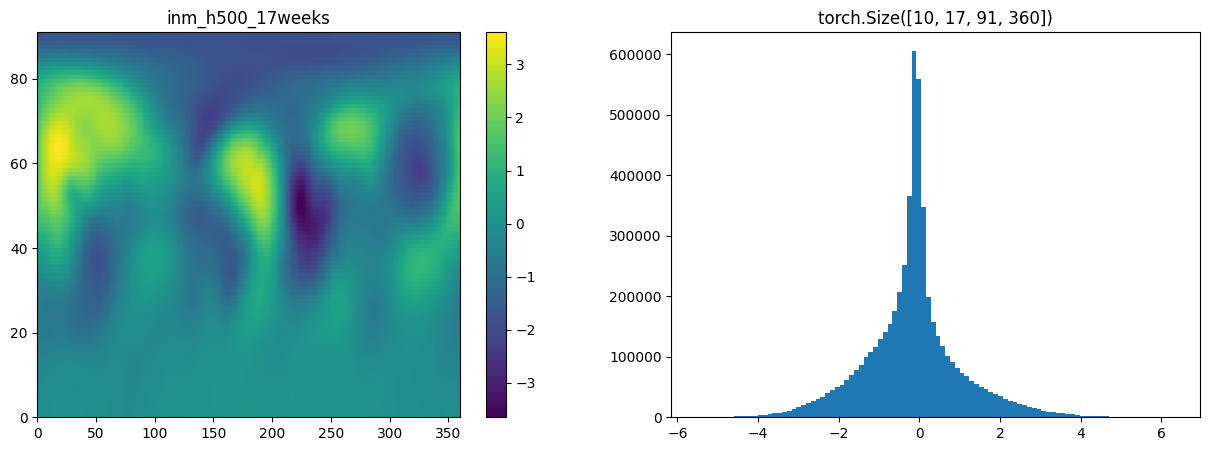

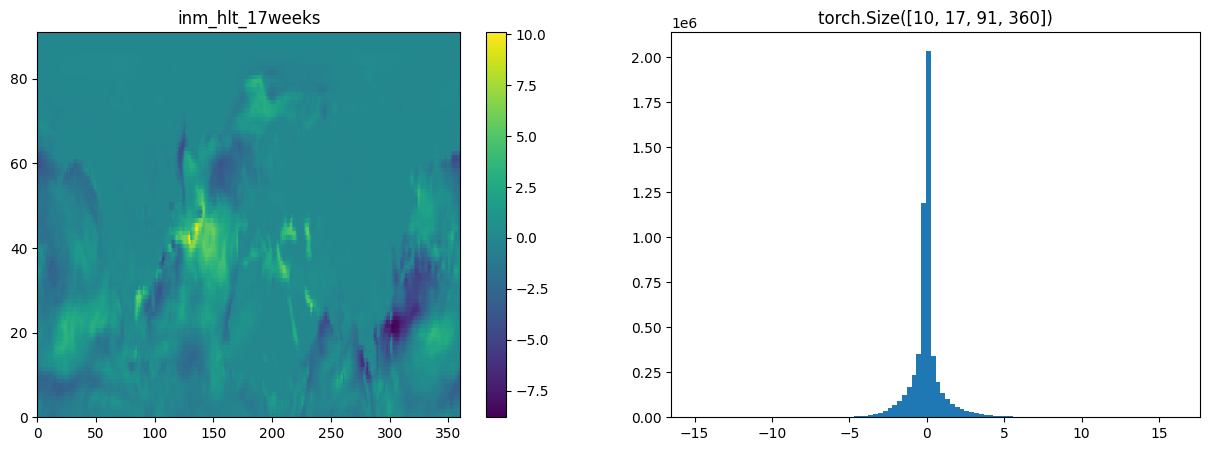

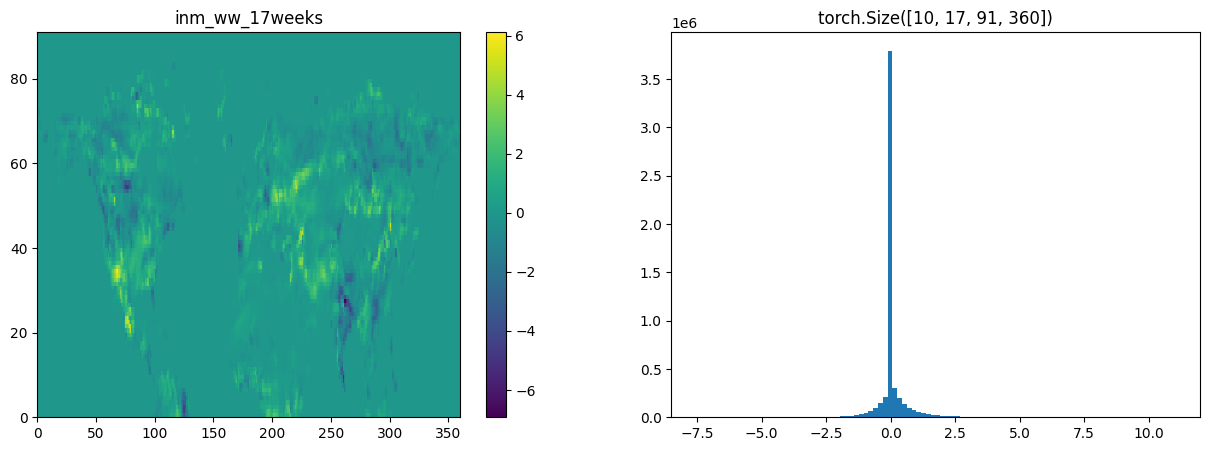

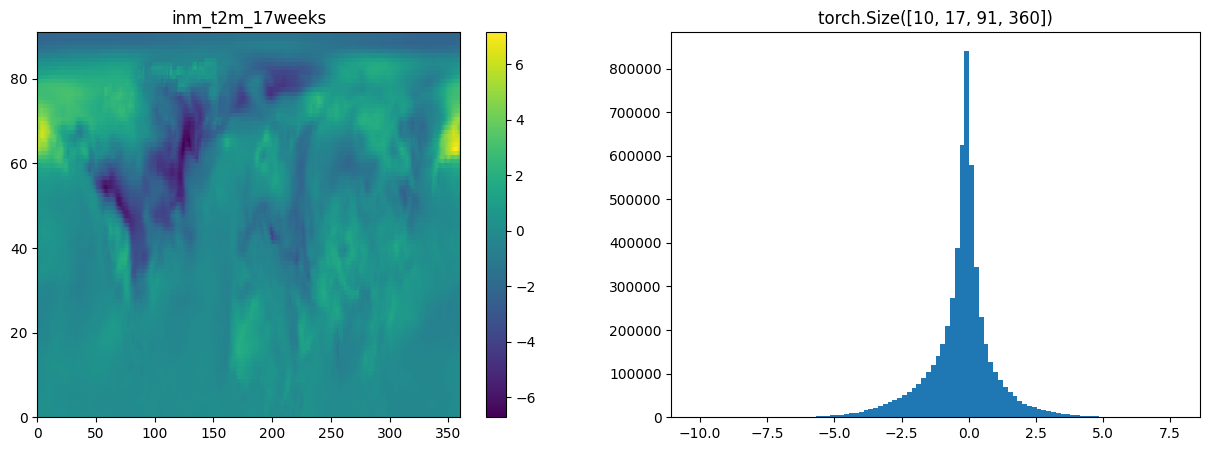

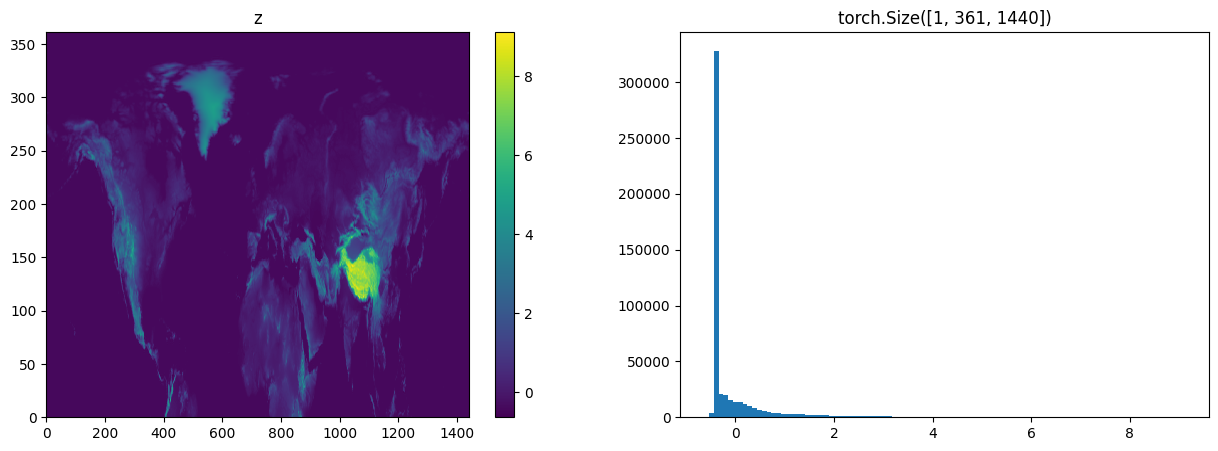

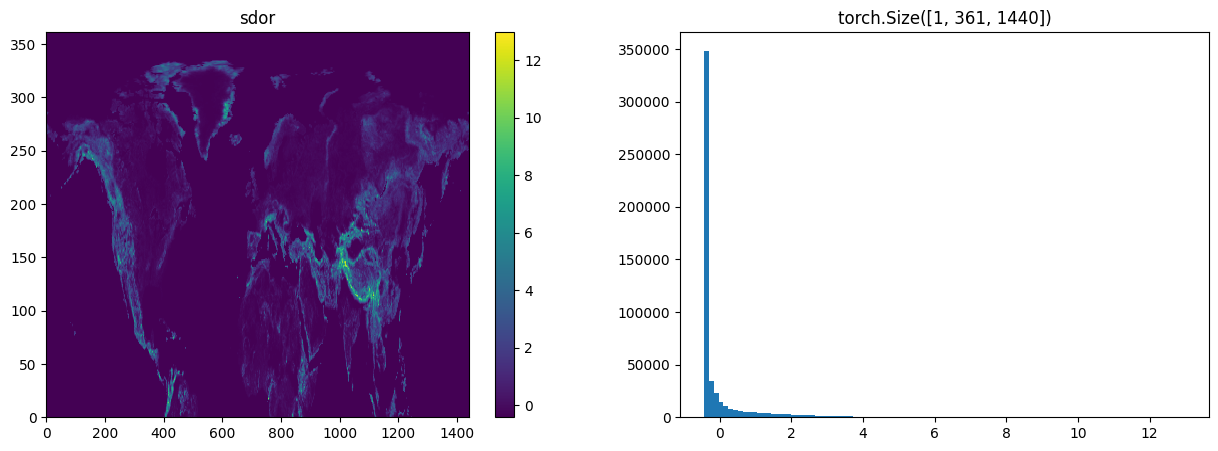

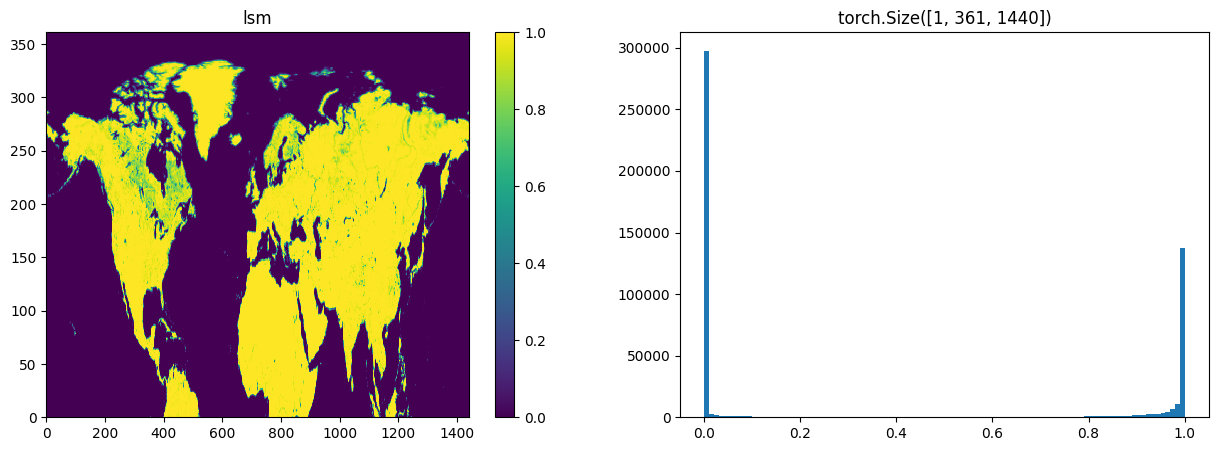

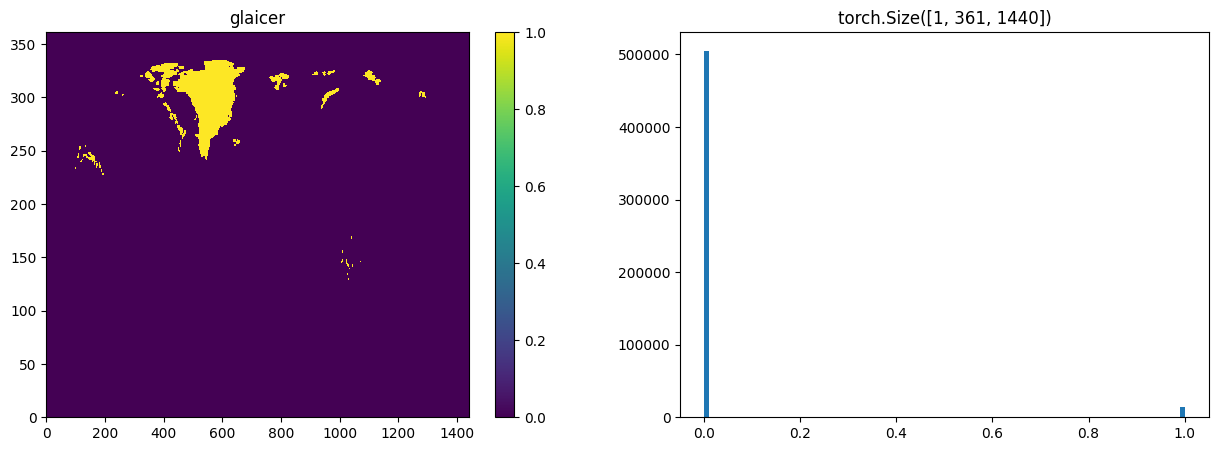

In [4]:
from scripts.utils import ContiguousDataset
from matplotlib import pyplot as plt

train_dates = pd.date_range('19910201', '20210101', freq='MS').strftime('%Y%m%d')

train_ds = ContiguousDataset(
    vars = {'era_vars': ['snow_cover', 'sd', 'sst', 't2m', 'tp', 'sden', 'pt'],
            'inm_vars': ['inm_swe', 'inm_ts', 'inm_mslp', 'inm_tp', 'inm_u850', 'inm_v850', 'inm_snow_cover', 'inm_olr', 'inm_h500', 'inm_hlt', 'inm_ww', 'inm_t2m'],  
            'surf_vars': ['z', 'sdor', 'lsm', 'glaicer']}, 
    dates = train_dates, 
    scales={'era_scales': 
    [  
        {'id': '6weeks', 'tStep': 7, 'tSize': 6},
        {'id': '6months', 'tStep': 30, 'tSize': 6}
        ]
    , 'inm_scales':
    [
        {'id': '17weeks', 'tSize': 17, 'tStep': 7}, # maximum lead time = 119-122 days, = 17 weeks
    ]})

idx = list(train_dates).index('19930101')
instnc = train_ds[idx]

for key, tensor in instnc.items():
    print(f'{key}: {tensor.shape}')
    if key.startswith('inm_lead_time'): 
        continue
    to_draw = tensor[0,0] if key.startswith('inm') else tensor[-1]
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(15,5)
    mesh = ax1.pcolormesh(to_draw)
    fig.colorbar(mesh, ax=ax1)
    ax1.set_title(key)
    ax2.hist(tensor.flatten(), bins=100)
    ax2.set_title(str(tensor.shape))

In [5]:
total = sum(t.element_size() * t.nelement() for t in instnc.values())
print(f'{total / 1024**2:.1f} MB')

429.4 MB


#### **Normalize**

 67%|██████▋   | 20/30 [00:05<00:02,  3.87it/s]/Users/a1/Desktop/arpp/v2/scripts/utils.py:172: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(1,2)
100%|██████████| 30/30 [00:08<00:00,  3.70it/s]


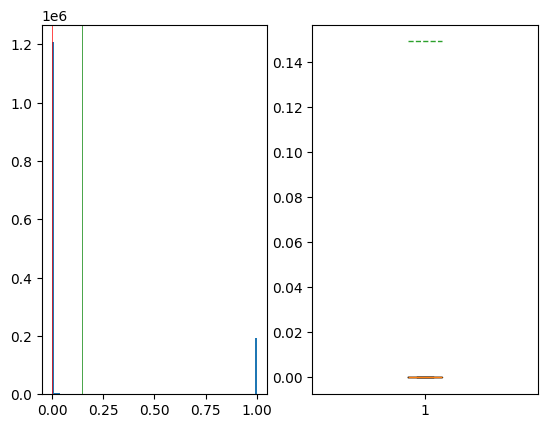

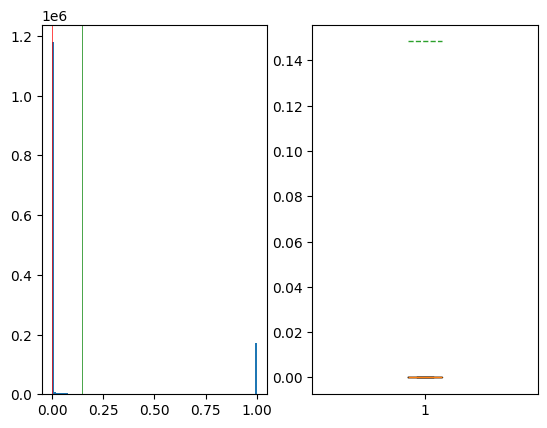

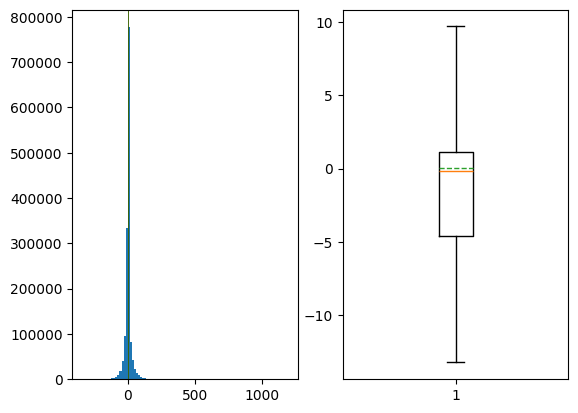

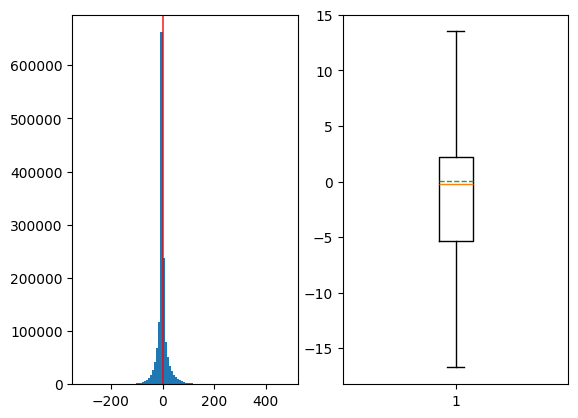

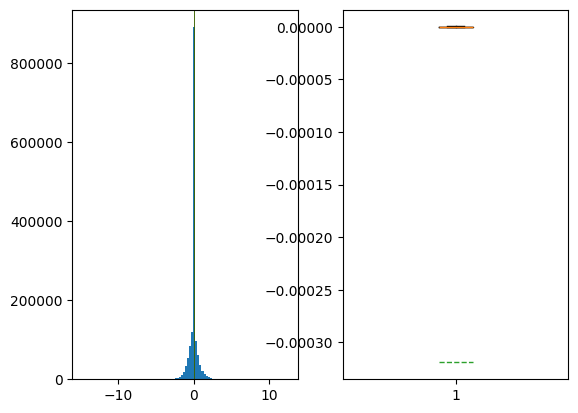

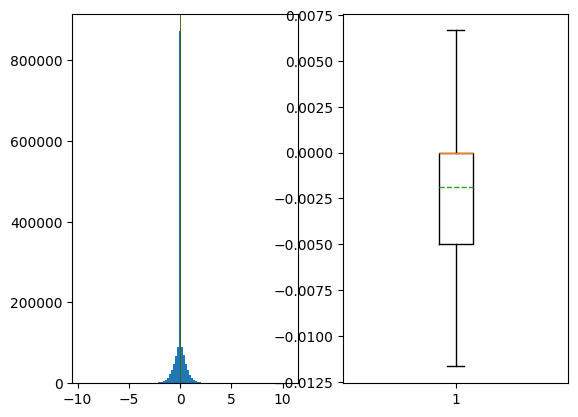

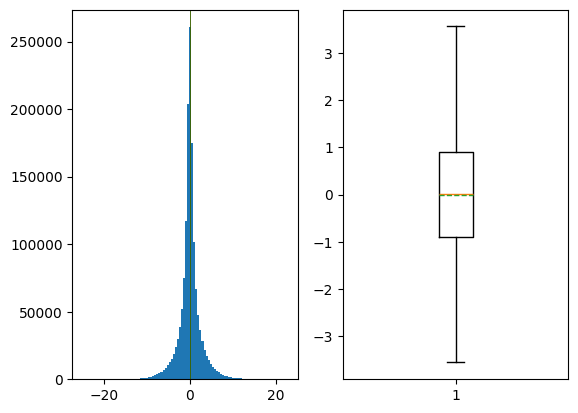

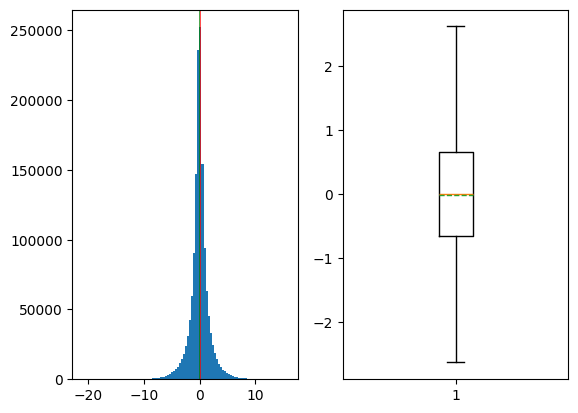

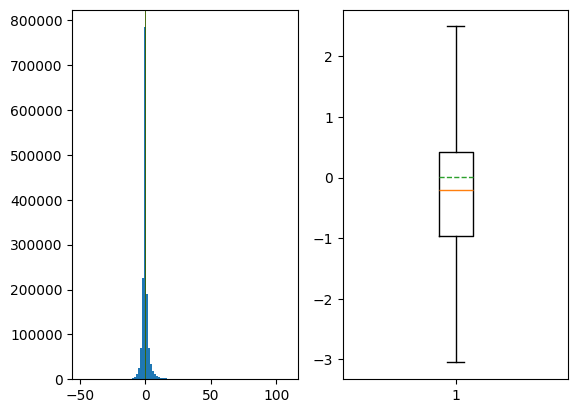

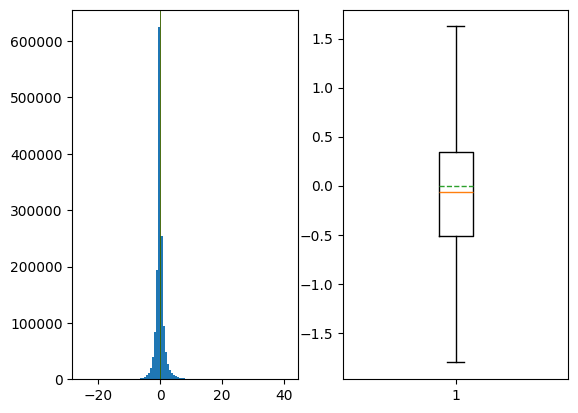

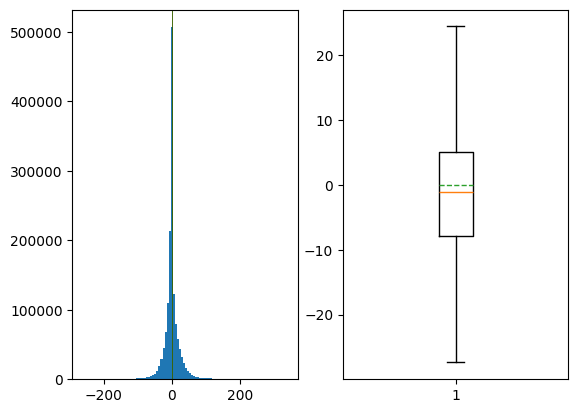

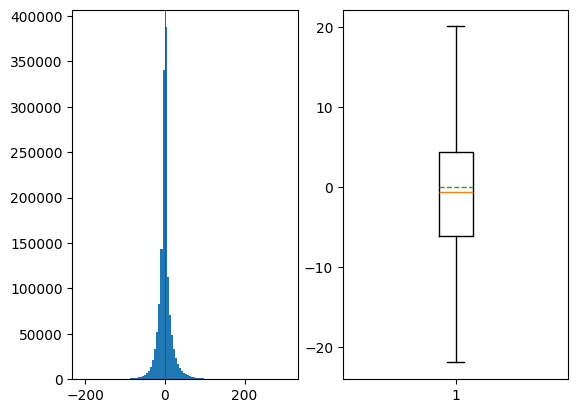

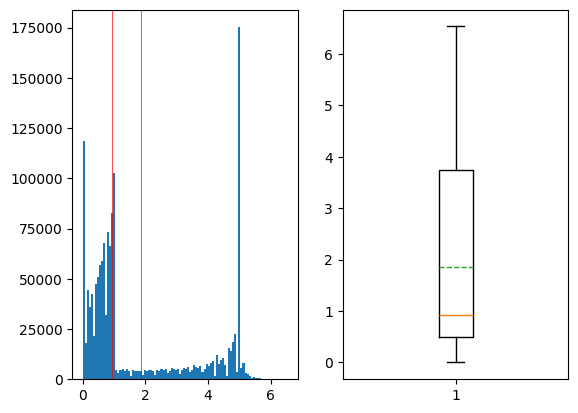

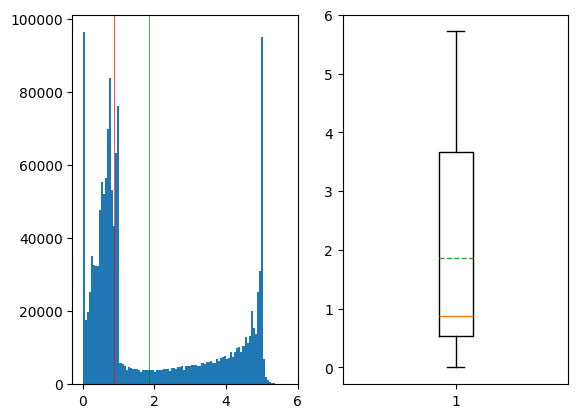

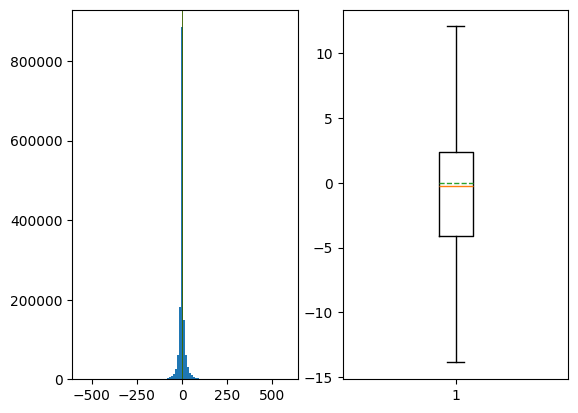

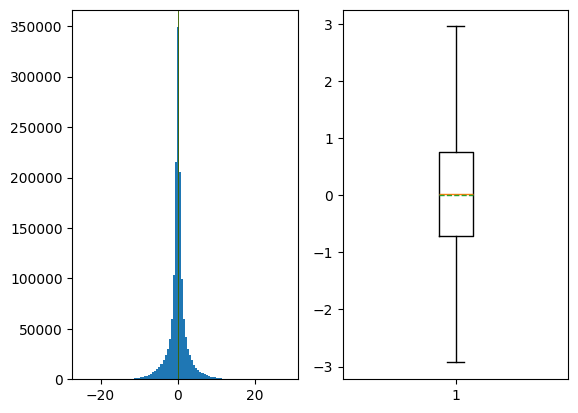

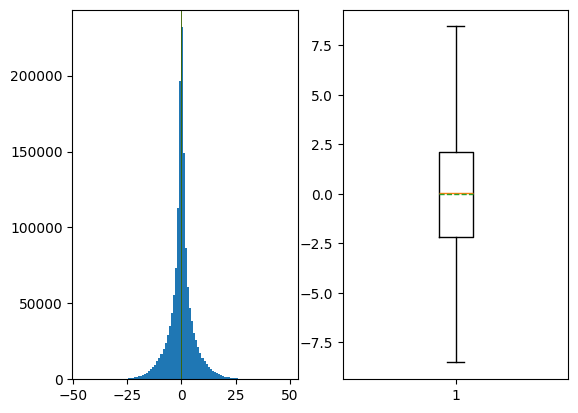

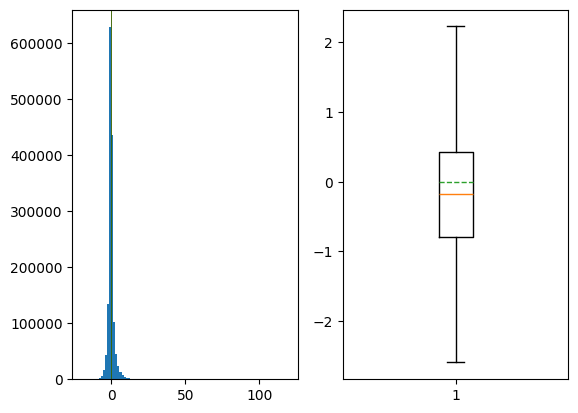

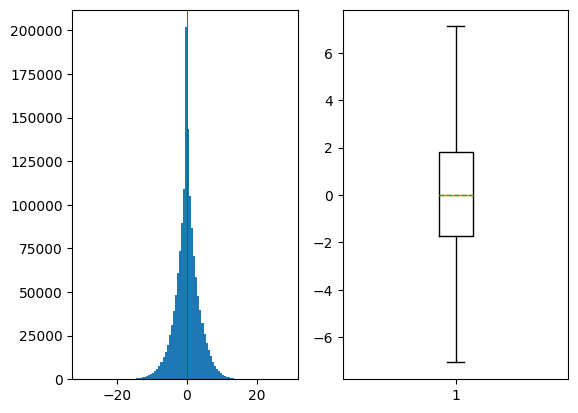

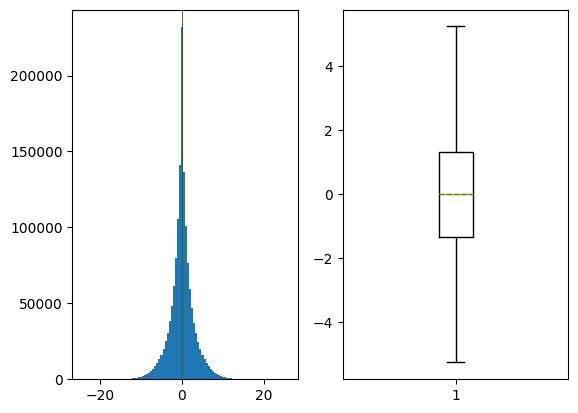

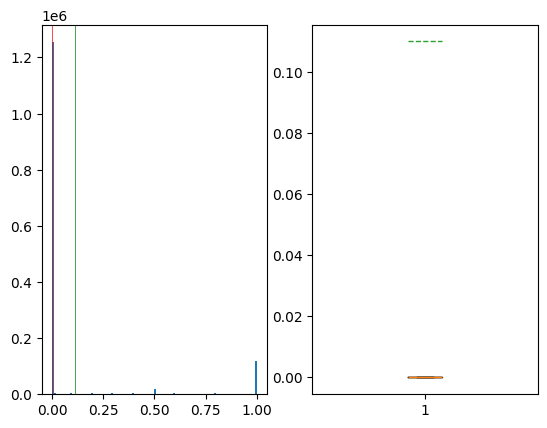

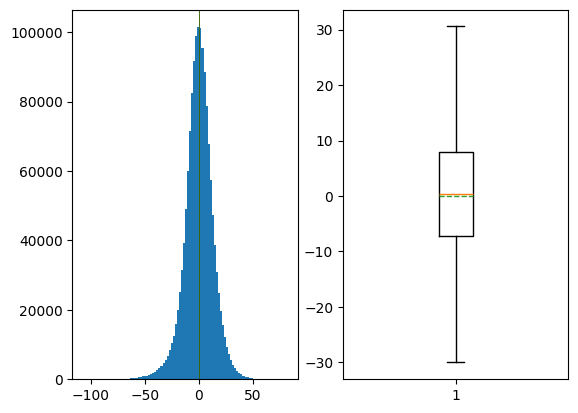

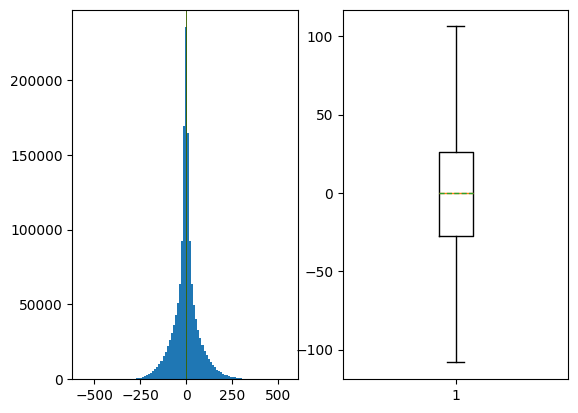

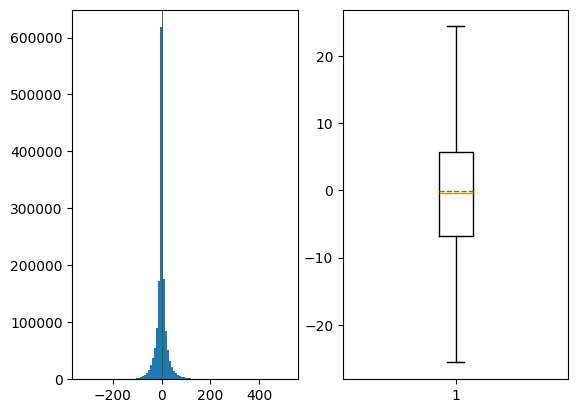

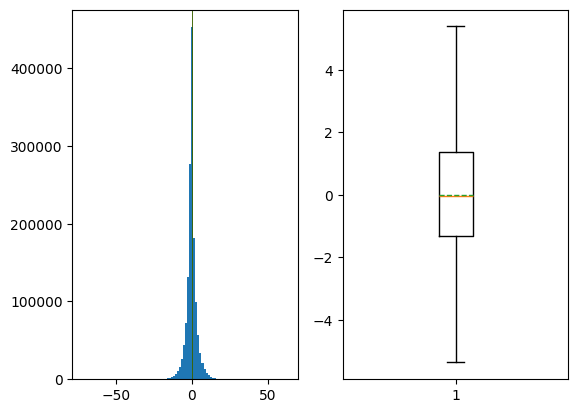

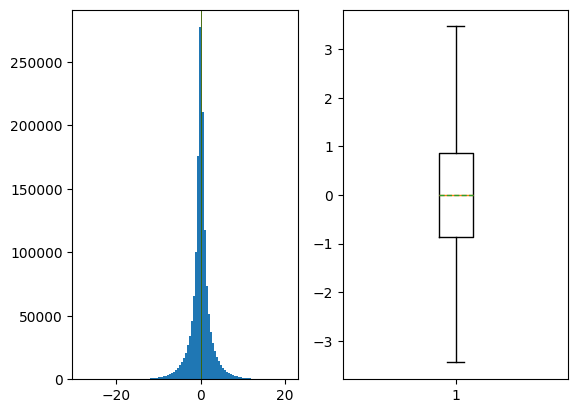

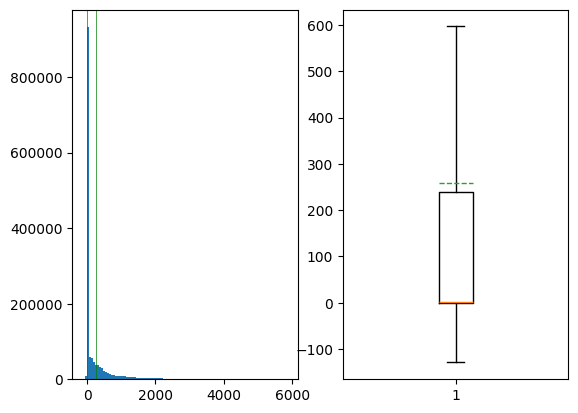

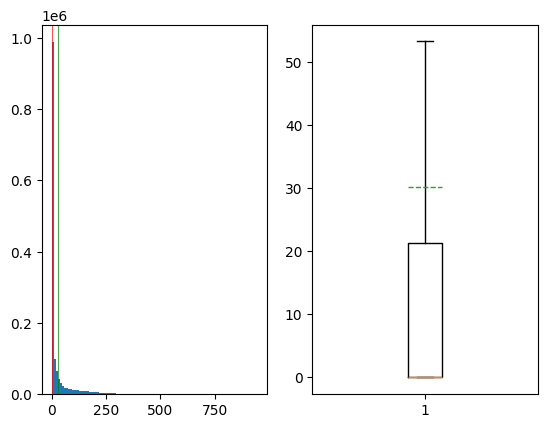

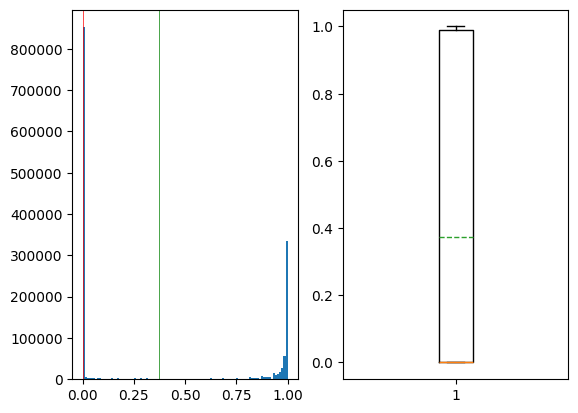

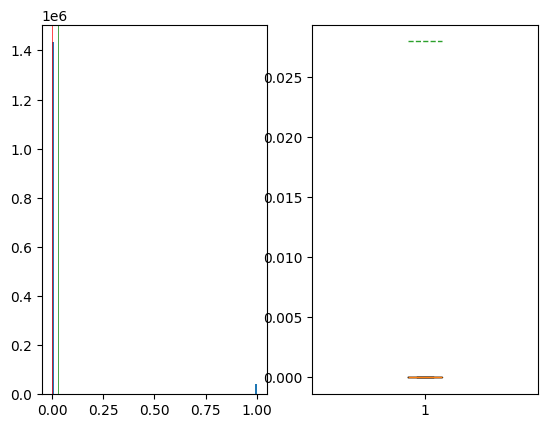

In [5]:
from scripts.utils import compute_norm
import json
import os

smpl_sz = 4096
reservoir = len(train_ds) * smpl_sz

stats = compute_norm(dataset=train_ds, 
                     reservoir=reservoir, 
                     sampl_sz=smpl_sz)

os.makedirs(f'database/norms/{train_ds.__class__.__name__}', exist_ok=True)
with open(f'database/norms/{train_ds.__class__.__name__}/{train_ds.__class__.__name__}.json', 'w') as f:
    json.dump(stats, f, default=str, indent=2)


In [6]:
request_weeks = patcher.Request('inm_swe', 0, 0,'20210101', 360, 91, 17, 1, 7, 1)
request_days = patcher.Request('inm_swe', 0, 0,'20210101', 360, 91, 120, 1, 1, 1)

tensors = patcher.load(patcher_context, [request_weeks, request_days])
for tensor in tensors: 
    print(torch.isnan(tensor).any(dim=(-2,-1))[0])


tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False])
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
      

In [7]:
with open('database/norms/ContiguousDataset/ContiguousDataset.json', 'r', encoding='utf-8') as file:
    norms = json.load(file)
norms['channels']

{'era_snow_cover_6weeks': {'n': 1122854400,
  'mean': 0.14907154930819191,
  'std': 0.3464251335128871,
  'mad_std': 0.0,
  'q001': 0.0,
  'q01': 0.0,
  'q25': 0.0,
  'q50': 0.0,
  'q75': 0.0,
  'q99': 1.0,
  'q999': 1.0},
 'era_snow_cover_6months': {'n': 1122854400,
  'mean': 0.14881094488169921,
  'std': 0.33916089024496177,
  'mad_std': 0.0,
  'q001': 0.0,
  'q01': 0.0,
  'q25': 0.0,
  'q50': 0.0,
  'q75': 0.0,
  'q99': 1.0,
  'q999': 1.0},
 'era_sd_6weeks': {'n': 209180598,
  'mean': 0.024860454155696824,
  'std': 27.56206111441085,
  'mad_std': 4.44779944768846,
  'q001': -145.97773400878907,
  'q01': -74.67142486572266,
  'q25': -4.64285945892334,
  'q50': -0.19999994337558746,
  'q75': 1.1000010967254639,
  'q99': 94.74285438537598,
  'q999': 184.43487207031404},
 'era_sd_6months': {'n': 218529553,
  'mean': 0.09795417176008374,
  'std': 25.496188758874965,
  'mad_std': 5.821676744368672,
  'q001': -138.0025548400879,
  'q01': -71.36469711303711,
  'q25': -5.393332004547119,
  '